# Análisis exploratorio de datos — Fraude

## Objetivo

El enunciado no pide detectar fraude: pide **maximizar la ganancia**. Cada transacción legítima aprobada
rinde el 25% de su monto y cada fraude aprobado pierde el 100%. Esas dos reglas son lo único que sabemos
antes de abrir el archivo, y alcanzan para fijar el criterio: cada cosa que encontremos se va a juzgar
por cuánto ayuda a ganar plata, no por cuánto fraude detecta.

Esta notebook no hace selección de variables ni entrena modelos. Ejecutar desde `notebooks/`, con el
entorno de uv y el CSV en `data/`. El material conceptual —Spearman frente a Pearson, cómo leer un KDE,
IQR, lift— se explica donde hace falta, sin repetirlo en cada sección.

Antes que nada, abrir el archivo y mirar qué hay.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import average_precision_score, roc_auc_score

from fraud_detection.constants import (
    AMOUNT,
    BINARY_COLUMNS,
    CATEGORICAL_COLUMNS,
    GAIN_RATE,
    NUMERIC_COLUMNS,
    N_SPLITS,
    TARGET,
    TEST_START,
)
from fraud_detection.dataset import load_transactions, normalize_text, split_development
from fraud_detection.diagnostics import iqr_report, rate_table, summarize_segments
from fraud_detection.evaluation import (
    expected_gain,
    gain_by_policy,
    max_gain,
    optimal_probability_threshold,
    sweep_gain,
)
from fraud_detection.modeling import temporal_folds
from fraud_detection.plots import plot_class_distribution, plot_gain_curve, plot_rate_table

df = load_transactions()
print(f"{len(df):,} transacciones | {df.shape[1]} columnas")
display(df.head())
display(
    pd.DataFrame(
        {
            "tipo": df.dtypes.astype(str),
            "valores_distintos": df.nunique(),
            "ejemplo": df.iloc[0].astype(str),
        }
    )
)

150,000 transacciones | 19 columnas


,a,b,c,d,e,f,g,h,j,k,l,m,n,o,p,fecha,monto,score,fraude
0,4,0.6812,50084.12,50.0,0.000000,20.0,AR,1,cat_d26ab52,0.365475,2479.0,952.0,1,NaN,Y,2020-03-20 09:28:19,57.63,100,0
1,4,0.6694,66005.49,0.0,0.000000,2.0,AR,1,cat_ea962fb,0.612728,2603.0,105.0,1,Y,Y,2020-03-09 13:58:28,40.19,25,0
2,4,0.4718,7059.05,4.0,0.463488,92.0,BR,25,cat_4c2544e,0.651835,2153.0,249.0,1,Y,Y,2020-04-08 12:25:55,5.77,23,0
3,4,0.7260,10043.10,24.0,0.046845,43.0,BR,43,cat_1b59ee3,0.692728,4845.0,141.0,1,N,Y,2020-03-14 11:46:13,40.89,23,0
4,4,0.7758,16584.42,2.0,0.154616,54.0,BR,0,cat_9bacaa5,0.201354,2856.0,18.0,1,Y,N,2020-03-23 14:17:13,18.98,71,0


,tipo,valores_distintos,ejemplo
a,int64,4,4
b,float64,7672,0.6812
c,float64,135090,50084.12
d,float64,51,50.0
e,float64,43208,0.0
f,float64,1338,20.0
g,str,51,AR
h,int64,59,1
j,str,8324,cat_d26ab52
k,float64,150000,0.3654752356846202


### Qué trae el dataset, y qué no

Salvo `fecha`, `monto`, `score` y `fraude`, los nombres son letras sueltas, de `a` a `p` y sin `i`.
**No hay diccionario de datos**, así que el significado de cada columna anónima es desconocido y no le
asignamos nombres de negocio: se las analiza por cómo se comportan, no por lo que suponemos que miden.

Lo que sí se lee de esta primera mirada: `g` trae códigos de dos letras que parecen países, `o` y `p`
toman `Y` y `N`, `n` es binaria, `score` es un entero y `j` tiene valores `cat_*` con muchísimos
niveles. Y algo que pesa por lo que **no** está: no hay columna de moneda, ni identificador de usuario,
ni la decisión de aprobación que tomó el sistema vigente.

De ahí salen cuatro supuestos que conviene declarar ahora, antes de analizar nada, porque si alguno
resulta falso cambia lo que se puede concluir:

| Supuesto | Estado | Qué pasa si es falso |
|---|---|---|
| `monto` está en una unidad monetaria común entre países | Sin confirmar: no hay columna de moneda | Las sumas globales de ganancia dejan de ser válidas: habría que convertir antes de optimizar |
| `g` es el país | Sugerido por los códigos de dos letras | Las comparaciones por país quedan como hipótesis |
| `score` está disponible al momento de decidir el pago | **Se evalúa en la sección 5** | Sería fuga de información y no puede usarse como predictor |
| Las etiquetas se confirman sin demora relevante | **Se evalúa en la sección 1** | El `gap` entre entrenamiento y validación queda mal fijado y los últimos días de cada fold no son confiables |

Los dos últimos se pueden evaluar con estos datos y se evalúan. Los dos primeros requieren el
diccionario y quedan abiertos; se retoman en las conclusiones.

### Cómo sigue

Recién ahora, sabiendo qué columnas hay, se puede armar el recorrido:

1. Reserva temporal y demora de etiquetas.
2. Calidad de datos.
3. Balance de clases y monto.
4. La economía del problema: de tasas a pesos, y de dónde sale el umbral de decisión.
5. `score`: si sirve como referencia y cuánto rinde, medido fuera de muestra.
6. Qué variables separan, y cuánto valen en pesos.
7. Correlaciones entre predictores.
8. País y tiempo.
9. Conclusiones.

## 1. Reserva temporal y demora de etiquetas

Antes de mirar los datos, dos cosas: validar el contrato del dataset y apartar el período de evaluación.

El contrato —columnas categóricas, binarias, objetivo y corte temporal— vive en
`fraud_detection.constants`, para que esta notebook y las de modelado no se desincronicen. La limpieza
se hace sobre una copia y los errores esenciales **detienen la ejecución** en lugar de corregirse en
silencio: una etiqueta inválida o un monto no positivo son un problema de origen, no algo a imputar.

**Por qué reservar por fecha y no al azar.** En producción el modelo siempre predice sobre
transacciones posteriores a las que vio al entrenar. Partir al azar mezclaría pasado y futuro y mediría
un problema que no existe. Por eso el corte es una fecha: `TEST_START`, el 13 de abril de 2020.

**Con qué criterio se eligió esa fecha**, fijado antes de mirar el resultado. Dos condiciones: que el
período reservado sea un múltiplo de semana, así contiene los siete días y no se sesga por composición
de días; y que deje afuera una fracción razonable de filas para un holdout, en el orden del 20 al 25%.
La celda siguiente muestra con qué proporción quedó.

**La demora de etiquetas.** Si un fraude tardara varios días en confirmarse, las transacciones más
recientes aparecerían como legítimas simplemente porque su fraude todavía no se detectó. Eso rompería
dos cosas: el `gap` entre entrenamiento y validación de cada fold, y la confiabilidad de los últimos
días de cualquier entrenamiento.

El síntoma sería visible en la tasa diaria de fraude: los últimos días del extracto caerían de forma
sostenida, y cuanto más cerca del final, más bajo, porque menos tiempo tuvieron para madurar. Eso es lo
que buscamos en el gráfico que sigue.

In [2]:
clean = normalize_text(df)

# Detenerse ante errores esenciales, en lugar de eliminarlos silenciosamente.
assert pd.api.types.is_datetime64_any_dtype(clean.fecha), "Revisar formato de fecha."
assert clean.fecha.notna().all(), "Revisar fechas ausentes."
assert clean[TARGET].isin([0, 1]).all(), "No imputar etiquetas desconocidas."
assert clean.monto.notna().all() and np.isfinite(clean.monto).all()
assert clean.monto.gt(0).all(), "Revisar montos no positivos y posibles devoluciones."
for col in BINARY_COLUMNS:
    assert clean[col].dropna().isin([0, 1]).all(), f"Revisar dominio de {col}."

numeric_columns = [
    col
    for col in clean.select_dtypes(include="number").columns
    if col not in CATEGORICAL_COLUMNS + BINARY_COLUMNS + [TARGET]
]
assert not np.isinf(clean[numeric_columns]).any().any(), "Revisar valores infinitos."
assert numeric_columns == NUMERIC_COLUMNS, "El contrato de columnas numéricas cambió."
print("Categóricas:", CATEGORICAL_COLUMNS, "| Numéricas:", numeric_columns)

Categóricas: ['a', 'g', 'j', 'o', 'p'] | Numéricas: ['b', 'c', 'd', 'e', 'f', 'h', 'k', 'l', 'm', 'monto', 'score']


Desarrollo: 114,506 filas, 36 días (08/03 a 12/04)
Reservado:  35,494 filas, 9 días (13/04 a 21/04), 23.7% de las filas


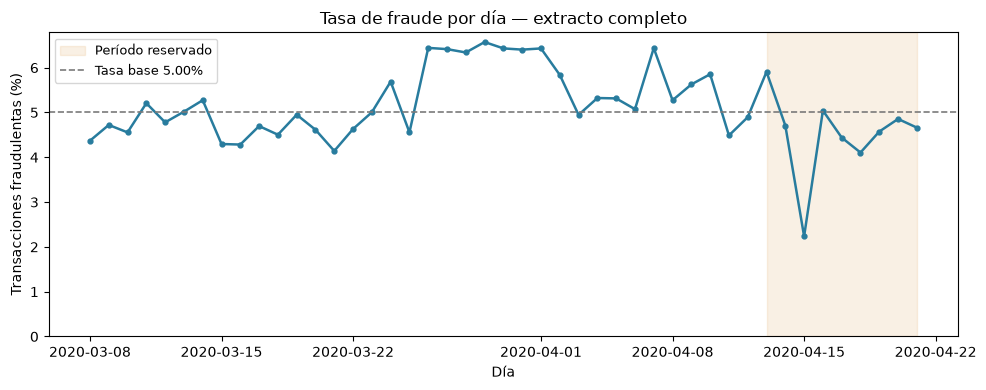


Últimos 3 días del extracto: 4.70% | los 42 anteriores: 5.14%
Últimos 5 días de desarrollo: 5.23% | los 31 anteriores: 5.27%
Día de menor tasa: 15/04 (2.24%)
Período reservado: 4.43% de fraude | desarrollo: 5.18%


In [3]:
development, test = split_development(clean)
assert len(development) + len(test) == len(clean)
print(
    f"Desarrollo: {len(development):,} filas, "
    f"{development.fecha.dt.normalize().nunique()} días "
    f"({development.fecha.min():%d/%m} a {development.fecha.max():%d/%m})"
)
print(
    f"Reservado:  {len(test):,} filas, {test.fecha.dt.normalize().nunique()} días "
    f"({test.fecha.min():%d/%m} a {test.fecha.max():%d/%m}), "
    f"{100 * len(test) / len(clean):.1f}% de las filas"
)

# Chequeo de integridad de etiquetas: es la única vez que se mira el período
# reservado y no decide nada del modelado.
diaria = (
    clean.assign(dia=clean.fecha.dt.normalize())
    .groupby("dia")
    .agg(transacciones=(TARGET, "size"), fraude_pct=(TARGET, "mean"))
)
diaria["fraude_pct"] *= 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(diaria.index, diaria.fraude_pct, marker="o", markersize=3.5, color="#287C9E", linewidth=1.8)
ax.axvspan(TEST_START, diaria.index.max(), color="#D38B28", alpha=0.12, label="Período reservado")
ax.axhline(
    clean[TARGET].mean() * 100,
    color="#7A7A7A",
    linestyle="--",
    linewidth=1.2,
    label=f"Tasa base {clean[TARGET].mean():.2%}",
)
ax.set(
    title="Tasa de fraude por día — extracto completo",
    xlabel="Día",
    ylabel="Transacciones fraudulentas (%)",
    ylim=(0, None),
)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

print(
    f"\nÚltimos 3 días del extracto: {diaria.fraude_pct.tail(3).mean():.2f}% | "
    f"los 42 anteriores: {diaria.fraude_pct.head(-3).mean():.2f}%"
)
print(
    f"Últimos 5 días de desarrollo: {diaria.fraude_pct.iloc[31:36].mean():.2f}% | "
    f"los 31 anteriores: {diaria.fraude_pct.iloc[:31].mean():.2f}%"
)
print(f"Día de menor tasa: {diaria.fraude_pct.idxmin():%d/%m} " f"({diaria.fraude_pct.min():.2f}%)")
print(
    f"Período reservado: {test[TARGET].mean():.2%} de fraude | "
    f"desarrollo: {development[TARGET].mean():.2%}"
)

**El corte, en números.** El extracto cubre **45 días corridos**. Los 9 reservados resultaron ser el
**23,7% de las filas**, dentro del rango que buscábamos, y dejan **36 días** de desarrollo. Ahí se toman
**todas** las decisiones y ahí corre después `TimeSeriesSplit` con `N_SPLITS = 4`.

**La demora de etiquetas: el patrón no aparece.** No hay derrumbe en la cola. Los últimos tres días del
extracto promedian 4,70% contra
5,14% de los 42 anteriores, y dentro de desarrollo los últimos cinco días (5,23%) están al nivel de los
anteriores (5,27%). Una demora de confirmación de *d* días produce un patrón distinto y reconocible: los
últimos *d* días caen de forma monótona hacia cero. Acá el día de menor tasa es el 15 de abril (2,24%),
un punto aislado en el medio del período reservado, no un descenso sostenido al final.

**Decisión: `gap = 0`, con una advertencia.** La evidencia disponible no muestra truncamiento, así que
entrenar y validar en días consecutivos es razonable. Pero este chequeo **no puede detectar una demora
uniforme más larga que la ventana observada**: si todas las etiquetas tardaran, por ejemplo, 60 días, el
extracto completo estaría igual de incompleto y el gráfico se vería idéntico. Por eso sigue siendo una
pregunta para el dueño del dato, y la respuesta tiene una consecuencia concreta y barata de aplicar:
`temporal_folds` ya recibe `gap_days`, así que basta volver a correr con el valor informado.

El período reservado tiene **4,43%** de fraude contra **5,18%** en desarrollo. La diferencia es
compatible tanto con una demora corta como con un cambio real de nivel, y no se puede distinguir sin el
dato externo. Se deja anotada, no resuelta.

De acá en adelante, **todas las tablas y gráficos usan solo desarrollo**.

## 2. Calidad de datos

Con el período reservado ya apartado, revisamos qué tan completo está lo que vamos a usar y cuánto
costaría "limpiarlo" con los reflejos habituales.

In [4]:
quality = pd.DataFrame(
    {
        "tipo": development.dtypes.astype(str),
        "nulos": development.isna().sum(),
        "nulos_pct": development.isna().mean() * 100,
        "valores_distintos": development.nunique(),
    }
)
display(quality.loc[quality.nulos.gt(0)].sort_values("nulos_pct", ascending=False).round(2))

print("Duplicados exactos:", development.duplicated().sum())
predictores = [col for col in development if col != TARGET]
repetidos = development.duplicated(subset=predictores, keep=False)
print(
    "Grupos de predictores idénticos con etiquetas distintas:",
    development.loc[repetidos].groupby(predictores, dropna=False)[TARGET].nunique().gt(1).sum(),
)

print()
print("Qué costaría eliminar toda fila con algún nulo:")
incompletas = development.isna().any(axis=1).rename("tiene_nulos")
display(
    rate_table(development, incompletas)[
        ["transacciones", "volumen_pct", "fraudes", "fraudes_pct"]
    ].round(2)
)

print("Qué costaría eliminar los extremos IQR de monto:")
limites = iqr_report(development, ["monto"]).loc["monto"]
extremos = (
    development.monto.lt(limites.limite_inferior) | development.monto.gt(limites.limite_superior)
).rename("monto_extremo")
display(rate_table(development, extremos)[["transacciones", "fraudes", "fraudes_pct"]].round(2))
print(f"f toma valores negativos en {development.f.lt(0).sum():,} filas")

,tipo,nulos,nulos_pct,valores_distintos
o,str,83014,72.50,2
b,float64,12653,11.05,7286
c,float64,12653,11.05,100699
d,float64,332,0.29,51
m,float64,332,0.29,1742
g,str,117,0.10,44
f,float64,11,0.01,1214
l,float64,11,0.01,7180


Duplicados exactos: 0


Grupos de predictores idénticos con etiquetas distintas: 0

Qué costaría eliminar toda fila con algún nulo:


,transacciones,volumen_pct,fraudes,fraudes_pct
tiene_nulos,,,,
False,27855,24.33,3623,61.11
True,86651,75.67,2306,38.89


Qué costaría eliminar los extremos IQR de monto:


,transacciones,fraudes,fraudes_pct
monto_extremo,,,
False,103293,4936,83.25
True,11213,993,16.75


f toma valores negativos en 971 filas


### Decisiones de limpieza

| Situación | Decisión en este EDA | Alternativa para validar después |
|---|---|---|
| Espacios y campos vacíos | Normalizar | Mantener la regla documentada |
| Nulos en predictores | Conservar | Mediana más indicador para numéricas; categoría de ausencia para categóricas |
| Muchos nulos en `o` | Conservar | Comprobar estabilidad y disponibilidad de la señal |
| Extremos plausibles de monto | Conservar | Logaritmo o escalado robusto si el modelo lo necesita |
| `f < 0` | Conservar sin corregir | Confirmar el significado de `f` en el diccionario |
| Duplicados | Auditar | Eliminar solo duplicación confirmada de ingestión |
| Target, fecha o monto inválidos | Detener y revisar | Recuperar desde la fuente |

**Conclusión: no se elimina nada.** No hay duplicados exactos ni grupos de predictores idénticos con
etiquetas en conflicto, así que no hay nada que auditar por ese lado. Pero limpiar por reflejo saldría
caro: `dropna()` descartaría el **75,7% de las transacciones y el 38,9% de los fraudes**, y recortar los
extremos IQR de monto se llevaría el **16,7% de los fraudes**. En un problema donde la clase positiva es
el 5% y los montos altos son los que más cuestan, las dos operaciones destruyen lo que venimos a medir.

Los negativos de `f` (971 filas) se conservan: el riesgo decae de forma continua al crecer `f`, sin salto
en el signo, así que son parte de su rango y no un error. Las transformaciones aprendidas —imputación, escalado, encoding— se
ajustan solo con el entrenamiento de cada fold, nunca sobre el dataset completo.

## 3. Balance de clases y monto

Miramos el desbalance, la cardinalidad de las categóricas y la distribución del monto, que es la
variable que convierte tasas en pesos.

,transacciones,porcentaje
fraude,,
No fraude,108577,94.82
Fraude,5929,5.18


,valores_distintos,nulos,nulos_pct
variable,,,
a,4,0,0.0
g,44,117,0.1
j,7770,0,0.0
o,2,83014,72.5
p,2,0,0.0


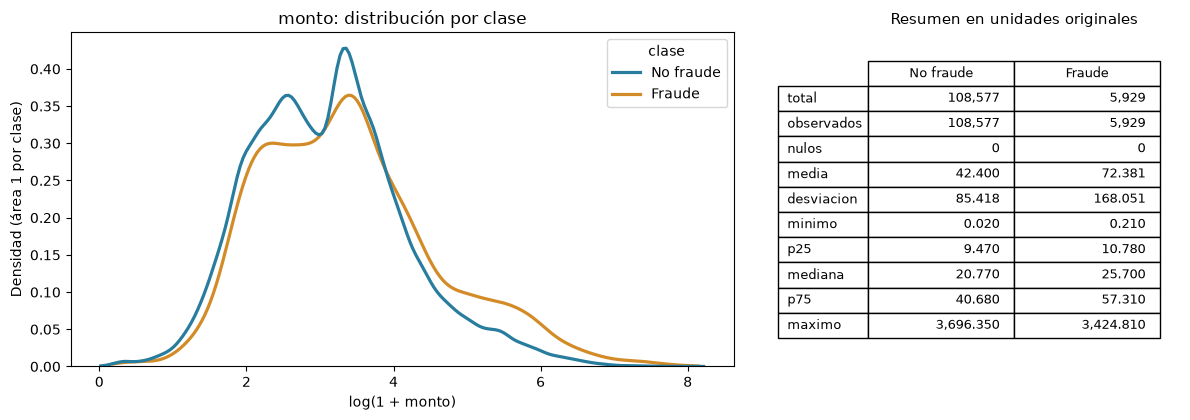

In [5]:
target_summary = (
    development[TARGET]
    .value_counts()
    .sort_index()
    .rename(index={0: "No fraude", 1: "Fraude"})
    .to_frame("transacciones")
)
target_summary["porcentaje"] = 100 * target_summary.transacciones / len(development)
display(target_summary.round(2))

cardinalidad = pd.DataFrame(
    [
        {
            "variable": col,
            "valores_distintos": development[col].nunique(),
            "nulos": int(development[col].isna().sum()),
            "nulos_pct": 100 * development[col].isna().mean(),
        }
        for col in CATEGORICAL_COLUMNS
    ]
).set_index("variable")
display(cardinalidad.round(2))

fig, amount_summary = plot_class_distribution(development, "monto", log_scale=True)
plt.show()

**Conclusión.** Fraude es el **5,18%** de desarrollo. En monto, la mediana pasa de **20,77** en no fraude
a **25,70** en fraude, y la media de **42,40** a **72,38**: el salto mucho mayor en la media es la cola
de montos altos, y es exactamente lo que hace que el problema se mida en pesos y no en transacciones.
Las curvas se superponen, así que el monto por sí solo no clasifica.

`j` tiene 7.770 valores distintos y `o` falta en el 72,5% de las filas. Son características a entender,
no motivos automáticos de exclusión: la sección 6 muestra que la ausencia de `o` es justamente una de
las señales más fuertes del dataset.

## 4. La economía del problema

Hasta acá medimos fraude en tasas. El enunciado se define en pesos, así que traducimos sus dos reglas a
una función que se pueda optimizar.

**La función de ganancia.** Para una política que aprueba un conjunto A de transacciones:

```
ganancia(A) = 0.25 * suma de monto de las legítimas en A
                   - suma de monto de los fraudes en A
```

**La decisión, transacción por transacción.** Para una de monto `m` a la que el modelo le asigna
probabilidad `p` de ser fraude:

| Acción | Qué pasa | Valor esperado |
|---|---|---|
| Rechazar | nada | `0` |
| Aprobar | con probabilidad `1 - p` gano `0.25 * m`; con probabilidad `p` pierdo `m` | `0.25 * m * (1 - p) - m * p` |

**El despeje.** Conviene aprobar cuando aprobar vale más que rechazar:

```
0.25 * m * (1 - p) - m * p  >  0
m * [0.25 * (1 - p) - p]    >  0     <- m es factor común
    0.25 * (1 - p) - p      >  0     <- dividir por m, válido porque m > 0
    0.25 - 0.25p - p        >  0
                     0.25   >  1.25p
                        p   <  0.2
```

El paso clave es dividir por `m`, legítimo porque ya verificamos con un `assert` que todos los montos
son estrictamente positivos. Al dividir, **el monto desaparece de la desigualdad**.

**Qué significa.** El umbral óptimo es `p < 0,2` para toda transacción: la de 5 y la de 3.696 se deciden
con el mismo corte. Suena contraintuitivo —uno esperaría ser más estricto con montos altos— pero no hace
falta, porque ganancia y pérdida escalan igual con el monto. Dicho simple: **por cada fraude que dejo
pasar necesito 4 transacciones legítimas del mismo monto para empatar**, y de ahí sale 1/5 = 0,2.

Que el monto se cancele en el umbral **no significa que el monto deje de importar**. Decide qué políticas
valen la pena: equivocarse en una transacción cara cuesta más, y por eso la sección 6 mide cada señal en
pesos y no solo en tasa. Si hubiera un costo fijo por rechazo o por revisión manual, ese costo no
escalaría con el monto y el umbral sí pasaría a depender de él; no es el caso de este enunciado.

**Consecuencia para el modelado.** La decisión usa el **valor** de `p`, no el orden. Un modelo con AUC
excelente pero probabilidades mal calibradas decide mal con este umbral.

In [6]:
todas = pd.Series(True, index=development.index)
politicas = {
    "Rechazar todo": ~todas,
    "Aprobar todo": todas,
    "Predicción perfecta": development[TARGET].eq(0),
}
display(gain_by_policy(development, politicas).round(2))

aprobar_todo = expected_gain(development, todas)
techo = max_gain(development)
print(f"Ganancia por legítima aprobada: {GAIN_RATE:.0%} del monto")
print(f"Umbral óptimo de probabilidad:  {optimal_probability_threshold():.2f}")
print(f"Monto total en desarrollo:      {development[AMOUNT].sum():,.0f}")
print(
    f"Monto en fraudes (exposición):  "
    f"{development.loc[development[TARGET].eq(1), AMOUNT].sum():,.0f}"
)
print(f"Brecha entre aprobar todo y predecir perfecto: {techo - aprobar_todo:,.0f}")

,ganancia,pct_del_maximo,aprobadas,aprobadas_pct,fraudes_aprobados
Rechazar todo,0.00,0.00,0.0,0.00,0.0
Aprobar todo,721774.18,62.71,114506.0,100.00,5929.0
Predicción perfecta,1150919.04,100.00,108577.0,94.82,0.0


Ganancia por legítima aprobada: 25% del monto
Umbral óptimo de probabilidad:  0.20
Monto total en desarrollo:      5,032,821
Monto en fraudes (exposición):  429,145
Brecha entre aprobar todo y predecir perfecto: 429,145


**Conclusión.** Aprobar todo deja **721.774** y una predicción perfecta daría **1.150.919**. La
diferencia, **429.145**, es el margen sobre el que compite cualquier modelo y el único número contra el
cual vale la pena compararse.

Un matiz importante sobre qué es ese número. **No es "el dinero que hoy se pierde por fraude":** es la
exposición bajo la política hipotética de *aprobar todo*. El dataset no trae la decisión de aprobación
del sistema vigente, así que no sabemos cuánto de eso se está evitando hoy. Y como toda suma en pesos,
depende del primero de los supuestos declarados: si `monto` mezclara monedas entre países, este total y
la optimización global no serían válidos hasta convertir a una unidad común.

## 5. `score`: la referencia que ya trae el dataset

`score` es un entero de 0 a 100 que viene con el dataset. El enunciado dice que los datos provienen
"del sistema de prevención de fraude de Mercado Libre", así que es plausible que sea la salida de ese
sistema, pero sin diccionario de datos no lo damos por confirmado.

Si resulta estar asociado con la etiqueta, define la vara: un modelo que no lo supere no aporta nada.
Eso abre dos preguntas que hay que responder antes de usarlo, en este orden: **¿es una fuga de
información?** y, si no lo es, **¿cuánta ganancia rinde realmente?**

Primero, cuánto separa.

,transacciones,volumen_pct,fraude_pct,lift,monto_en_fraude
score,,,,,
"(-0.001, 10.0]",13991,12.22,2.99,0.58,25422.03
"(10.0, 20.0]",11193,9.78,4.96,0.96,25975.04
"(20.0, 30.0]",10964,9.58,2.36,0.46,16226.47
"(30.0, 40.0]",11117,9.71,0.36,0.07,1731.69
"(40.0, 50.0]",11288,9.86,0.91,0.18,4591.80
"(50.0, 60.0]",11030,9.63,1.21,0.23,6919.53
"(60.0, 70.0]",11460,10.01,2.84,0.55,24104.27
"(70.0, 80.0]",11631,10.16,6.04,1.17,54111.73
"(80.0, 90.0]",12112,10.58,10.38,2.00,122333.66


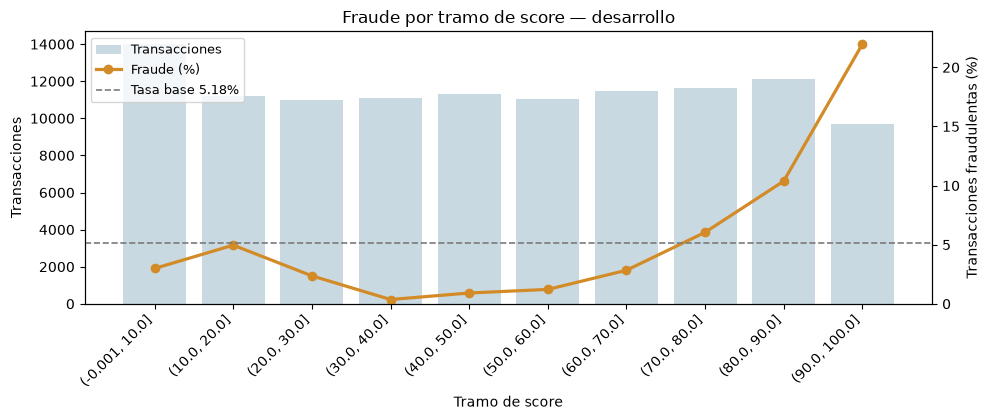

AUC de score solo:   0.7233
Average precision:   0.1690
Tasa base de fraude: 0.0518


In [7]:
score_buckets = rate_table(development, "score", bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
display(
    score_buckets[["transacciones", "volumen_pct", "fraude_pct", "lift", "monto_en_fraude"]].round(
        2
    )
)
fig = plot_rate_table(
    score_buckets, title="Fraude por tramo de score — desarrollo", ylabel="Tramo de score"
)
plt.show()

print(f"AUC de score solo:   {roc_auc_score(development[TARGET], development.score):.4f}")
print(f"Average precision:   {average_precision_score(development[TARGET], development.score):.4f}")
print(f"Tasa base de fraude: {development[TARGET].mean():.4f}")

### ¿`score` es una fuga de información?

Si `score` se calculara *después* de conocer el resultado de la transacción, sería inutilizable: el
modelo aprendería la respuesta y se caería en producción. No tenemos el diccionario de datos, pero sí
tres huellas que una variable filtrada dejaría y que se pueden medir.

In [8]:
semanal = development.assign(semana=development.fecha.dt.to_period("W-SUN").dt.start_time)
estabilidad = semanal.groupby("semana").apply(
    lambda g: pd.Series(
        {
            "transacciones": len(g),
            "fraude_pct": 100 * g[TARGET].mean(),
            "auc_score": roc_auc_score(g[TARGET], g.score),
            "score_mediano": g.score.median(),
        }
    ),
    include_groups=False,
)
display(estabilidad.round(3))

tope = development.loc[development.score.eq(100)]
print(f"score = 100 exacto: {len(tope):,} transacciones, {tope[TARGET].mean():.2%} de fraude")
print(
    f"Tramo 0-20:         {development.score.le(20).sum():,} transacciones, "
    f"{development.loc[development.score.le(20), TARGET].mean():.2%} de fraude"
)
print(
    f"AUC semanal: entre {estabilidad.auc_score.min():.4f} y "
    f"{estabilidad.auc_score.max():.4f} (desvío {estabilidad.auc_score.std():.4f})"
)

,transacciones,fraude_pct,auc_score,score_mediano
semana,,,,
2020-03-02,2838.0,4.369,0.764,53.0
2020-03-09,24523.0,4.828,0.718,52.0
2020-03-16,25199.0,4.560,0.716,53.0
2020-03-23,20069.0,5.690,0.732,52.0
2020-03-30,17434.0,5.782,0.733,45.0
2020-04-06,24443.0,5.409,0.725,44.0


score = 100 exacto: 1,617 transacciones, 29.50% de fraude
Tramo 0-20:         25,184 transacciones, 3.86% de fraude
AUC semanal: entre 0.7161 y 0.7637 (desvío 0.0174)


**Las tres huellas, y qué dicen.**

| Huella de una variable filtrada | Qué se observa | Lectura |
|---|---|---|
| El tramo más alto sería casi todo fraude | `score = 100` tiene **29,50%** de fraude | No se comporta como la etiqueta disfrazada |
| El AUC sería cercano a 1 | **0,7233** sobre desarrollo | Es un predictor útil pero lejos de perfecto |
| La relación sería monótona y limpia | El tramo 0-20 tiene **3,86%**, muy por encima del piso de **0,36%** del tramo 30-40 | Una etiqueta filtrada no produciría esa banda anómala |

Además, el AUC semanal se mantiene entre **0,7161 y 0,7637** (desvío 0,0174) a lo largo de las seis
semanas: es el comportamiento de un modelo en producción corriendo de forma continua, no el de un
cálculo hecho una vez sobre el resultado ya conocido.

**Conclusión: la evidencia es compatible con un puntaje calculado antes de decidir, no con una fuga.**
Es evidencia, no prueba, así que la pregunta sigue abierta para el dueño del dato. Pero como no es
gratis equivocarse, la decisión práctica es la que no depende de la respuesta: **medir el modelo con y
sin `score`**. Si el dueño del dato confirma que no está disponible al decidir el pago, la vara ya está
calculada y no hay que rehacer el trabajo. Queda anotado para `03_modeling.ipynb`.

La banda 0-20 queda como observación abierta: son 25.184 transacciones, así que no es ruido, y no le
inventamos explicación.

### ¿Cuánta ganancia rinde `score`?

La mejor regla de un solo corte es "aprobar si `score < t`". Pero elegir `t` sobre todo desarrollo y
después reportar la ganancia de ese mismo `t` sobre esos mismos datos da un número optimista: el corte
se ajustó a los datos con los que se lo mide. La vara honesta es temporal — **elegir el corte con el
pasado de cada fold y medirlo en su futuro** — que es exactamente la situación de producción.

In-sample: mejor corte 91 -> 757,218 (+35,444 sobre aprobar todo)


,dias_train,dias_validacion,filas_validacion,corte_elegido,mejor_corte_posible,aprobar_todo,mejora_real,mejora_maxima
fold,,,,,,,,
0,8,7,25199,93,99,189217.43,-1126.63,2792.88
1,15,7,20069,98,96,122877.61,1074.07,2142.47
2,22,7,17434,95,86,85648.10,7211.78,20153.72
3,29,7,24443,93,86,128268.77,16839.51,27515.08


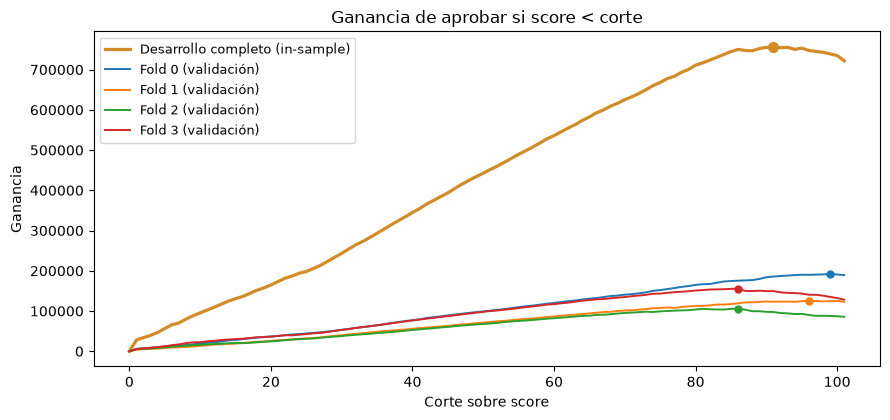

Mejora fuera de muestra, sumando los 4 folds: 23,999
Mejora si el corte se eligiera sobre la propia validación: 52,604
La regla captura el 45.6% de lo que promete la vista in-sample


In [9]:
cortes = range(102)
curva_total = sweep_gain(development, development.score, cortes)
print(
    f"In-sample: mejor corte {curva_total.idxmax()} -> {curva_total.max():,.0f} "
    f"({curva_total.max() - aprobar_todo:+,.0f} sobre aprobar todo)"
)

curvas = {"Desarrollo completo (in-sample)": curva_total}
filas = []
for numero, (train_pos, valid_pos) in enumerate(
    temporal_folds(development.fecha, n_splits=N_SPLITS)
):
    train, valid = development.iloc[train_pos], development.iloc[valid_pos]
    corte = sweep_gain(train, train.score, cortes).idxmax()  # elegido solo con el pasado
    curva_valid = sweep_gain(valid, valid.score, cortes)
    sin_regla = expected_gain(valid, pd.Series(True, index=valid.index))
    curvas[f"Fold {numero} (validación)"] = curva_valid
    filas.append(
        {
            "dias_train": train.fecha.dt.normalize().nunique(),
            "dias_validacion": valid.fecha.dt.normalize().nunique(),
            "filas_validacion": len(valid),
            "corte_elegido": corte,
            "mejor_corte_posible": curva_valid.idxmax(),
            "aprobar_todo": sin_regla,
            "mejora_real": expected_gain(valid, valid.score.lt(corte)) - sin_regla,
            "mejora_maxima": curva_valid.max() - sin_regla,
        }
    )
folds = pd.DataFrame(filas)
folds.index.name = "fold"
display(folds.round(2))

fig = plot_gain_curve(
    curvas, title="Ganancia de aprobar si score < corte", xlabel="Corte sobre score"
)
plt.show()

print(f"Mejora fuera de muestra, sumando los 4 folds: {folds.mejora_real.sum():,.0f}")
print(
    f"Mejora si el corte se eligiera sobre la propia validación: "
    f"{folds.mejora_maxima.sum():,.0f}"
)
print(
    f"La regla captura el {100 * folds.mejora_real.sum() / folds.mejora_maxima.sum():.1f}% "
    f"de lo que promete la vista in-sample"
)

**Conclusión: la vara real es bastante más baja de lo que parece.**

Sobre todo desarrollo, el mejor corte es `score < 91` y rinde **757.218**, es decir **+35.444** sobre
aprobar todo. Ese número es in-sample y no se puede usar como objetivo. Medido fuera de muestra, el
corte que elige cada fold cambia —**93, 98, 95 y 93**— y la mejora sumada sobre las cuatro validaciones
es **+23.999**: apenas el **45,6%** de lo que promete la vista optimista.

Hay un resultado que conviene no esconder: **en el fold 0 la regla pierde plata, −1.127**. Es el fold
más chico (8 días de entrenamiento) y el corte aprendido ahí, 93, no se sostiene en su validación, donde
el mejor habría sido 99. Es la demostración concreta de por qué la vara tenía que medirse así.

**La vara para `03_modeling.ipynb`:** superar una mejora de unos **24.000** medida fuera de muestra, no
los 35.444 del ajuste in-sample. Sobre una brecha disponible de 429.145, ni siquiera el número optimista
llega al 10%: hay muchísimo margen para un modelo.

## 6. Qué variables separan, y cuánto valen

Acá es donde la economía cambia el análisis. La tentación es ordenar las variables por tasa de fraude o
por `lift` y quedarse con las más altas. Pero un segmento con riesgo alto y poco monto puede no valer
nada, y uno con riesgo moderado y mucho volumen puede costar una fortuna si se lo rechaza.

Por eso cada segmento candidato se mide con **cuatro columnas que responden preguntas distintas**:
cuánta gente toca (`transacciones`), cuán riesgoso es (`fraude_pct`, `lift`), cuánta plata hay expuesta
(`monto_en_fraude`) y —la que decide— **cuánto cambiaría la ganancia si se rechazara ese segmento
entero** frente a aprobar todo.

Esto es una tabla descriptiva sobre datos con etiqueta conocida, no un modelo ni selección de variables:
sirve para saber dónde mirar, no para fijar reglas de producción.

In [10]:
hora = development.fecha.dt.hour
apariciones_j = development.j.map(development.j.value_counts())
segmentos = {
    "o = N": development.o.eq("N"),
    "o = N y n = 0": development.o.eq("N") & development.n.eq(0),
    "n = 0": development.n.eq(0),
    "score >= 90": development.score.ge(90),
    "hora entre 0 y 5": hora.lt(6),
    "a en {1, 3}": development.a.isin([1, 3]),
    "j con más de 500 apariciones": apariciones_j.gt(500),
    "h = 0": development.h.eq(0),
    "p = N": development.p.eq("N"),
    "o ausente": development.o.isna(),
}

filas = []
for nombre, mascara in segmentos.items():
    mascara = mascara.fillna(False)
    grupo = development.loc[mascara]
    monto_total = grupo[AMOUNT].sum()
    en_fraude = grupo.loc[grupo[TARGET].eq(1), AMOUNT].sum()
    filas.append(
        {
            "segmento": nombre,
            "transacciones": int(mascara.sum()),
            "volumen_pct": 100 * mascara.mean(),
            "fraude_pct": 100 * grupo[TARGET].mean(),
            "lift": grupo[TARGET].mean() / development[TARGET].mean(),
            "monto_en_fraude": en_fraude,
            "pct_del_monto_en_fraude": 100 * en_fraude / monto_total,
            "ganancia_si_se_rechaza": expected_gain(development, ~mascara) - aprobar_todo,
        }
    )
senales = (
    pd.DataFrame(filas).set_index("segmento").sort_values("ganancia_si_se_rechaza", ascending=False)
)
display(senales.round(2))

umbral = 100 * optimal_probability_threshold()
print(f"Umbral de rentabilidad: rechazar conviene si pct_del_monto_en_fraude > {umbral:.0f}%")
print(
    "¿El signo de la ganancia coincide con esa regla en los",
    len(senales),
    "segmentos?",
    bool(
        (senales.pct_del_monto_en_fraude.gt(umbral) == senales.ganancia_si_se_rechaza.gt(0)).all()
    ),
)

,transacciones,volumen_pct,fraude_pct,lift,monto_en_fraude,pct_del_monto_en_fraude,ganancia_si_se_rechaza
segmento,,,,,,,
o = N,12969,11.33,22.74,4.39,222995.69,32.97,109636.61
o = N y n = 0,3529,3.08,36.95,7.14,93792.58,51.17,71412.47
n = 0,11005,9.61,16.80,3.24,135188.71,27.06,44102.33
score >= 90,10922,9.54,21.18,4.09,160501.59,23.99,33368.67
hora entre 0 y 5,4340,3.79,11.59,2.24,41040.30,22.69,6073.15
"a en {1, 3}",5474,4.78,9.06,1.75,60238.41,12.42,-45959.17
j con más de 500 apariciones,14539,12.70,6.79,1.31,109934.06,14.57,-51201.39
h = 0,9784,8.54,9.57,1.85,79686.57,12.81,-55891.35
p = N,50779,44.35,7.92,1.53,291394.73,12.66,-211313.12


Umbral de rentabilidad: rechazar conviene si pct_del_monto_en_fraude > 20%
¿El signo de la ganancia coincide con esa regla en los 10 segmentos? True


**El umbral 0,2 reaparece, ahora por segmento.** La última verificación no es un detalle: rechazar un
segmento conviene **exactamente cuando más del 20% de su monto está en fraude**, y el signo coincide en
los diez casos. Es el mismo `p < 0,2` de la sección 4, aplicado a un grupo en vez de a una transacción.
La diferencia práctica es cuál es la tasa que importa: **la participación del fraude en el monto**, no en
el conteo. Por eso `n = 0` conviene rechazarlo con 16,80% de fraude en transacciones —sus fraudes son
caros y llegan al 27,06% del monto— mientras que `h = 0`, con 9,57%, no.

Los dos gráficos que siguen son para las dos señales donde la *forma* dice algo que la tabla no muestra.

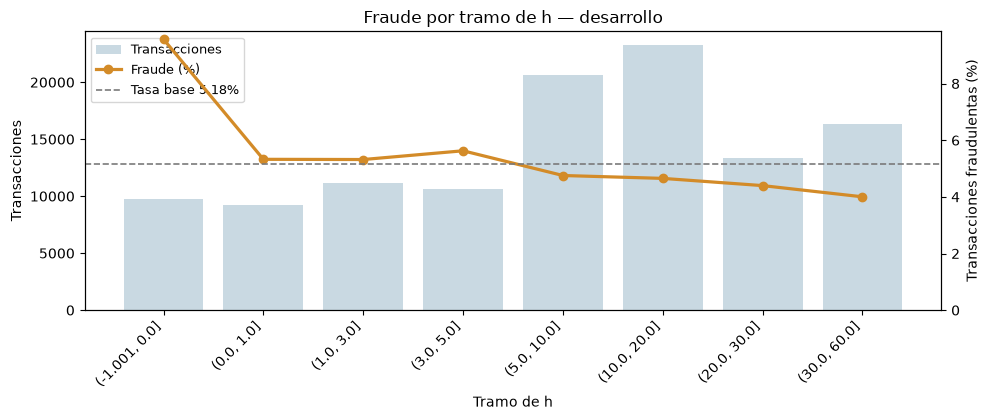

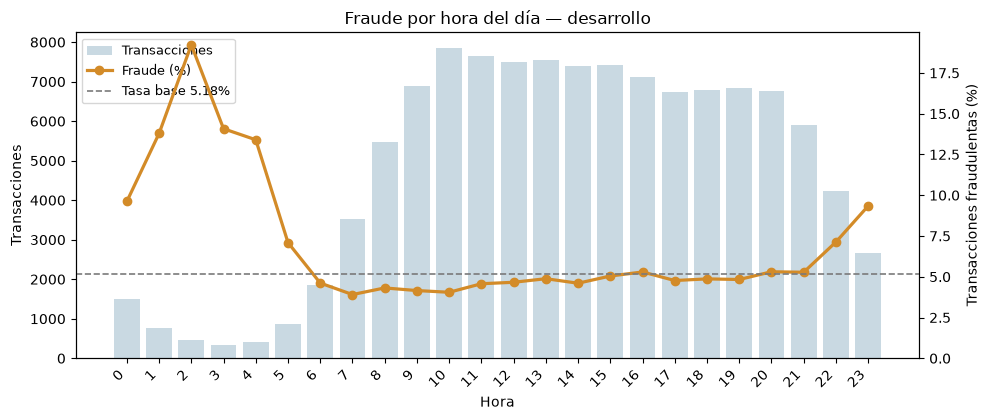

In [11]:
h_buckets = rate_table(development, "h", bins=[-1, 0, 1, 3, 5, 10, 20, 30, 60])
fig = plot_rate_table(h_buckets, title="Fraude por tramo de h — desarrollo", ylabel="Tramo de h")
plt.show()

tiempo = development.assign(
    hora=hora, dia_semana=development.fecha.dt.dayofweek, finde=development.fecha.dt.dayofweek.ge(5)
)
hora_tabla = rate_table(tiempo, "hora")
fig = plot_rate_table(hora_tabla, title="Fraude por hora del día — desarrollo", ylabel="Hora")
plt.show()

In [12]:
# Lo que se midió y no dio: reportarlo acota el trabajo de la etapa siguiente.
print(
    f"k — AUC: {roc_auc_score(development[TARGET], development.k):.4f} | "
    f"Spearman con el orden temporal: "
    f"{development.k.corr(development.fecha.astype('int64'), method='spearman'):.4f}"
)
print(
    f"j — {development.j.nunique():,} valores distintos, "
    f"{development.groupby('j').g.nunique().mean():.2f} países por valor en promedio"
)
display(
    rate_table(
        development, apariciones_j.rename("apariciones_de_j"), bins=[0, 1, 5, 20, 100, 500, 2000]
    )[["transacciones", "fraude_pct", "lift"]].round(2)
)
negativas = pd.concat(
    [
        rate_table(tiempo, "dia_semana")[["transacciones", "fraude_pct", "lift"]],
        rate_table(tiempo, "finde")[["transacciones", "fraude_pct", "lift"]],
    ]
)
display(negativas.round(2))

k — AUC: 0.5061 | Spearman con el orden temporal: 0.0035
j — 7,770 valores distintos, 1.26 países por valor en promedio


,transacciones,fraude_pct,lift
apariciones_de_j,,,
"(-0.001, 1.0]",2302,3.21,0.62
"(1.0, 5.0]",7743,3.25,0.63
"(5.0, 20.0]",19131,3.94,0.76
"(20.0, 100.0]",38568,5.13,0.99
"(100.0, 500.0]",32223,5.85,1.13
"(500.0, 2000.0]",14539,6.79,1.31


,transacciones,fraude_pct,lift
0,18342,4.97,0.96
1,17794,5.42,1.05
2,17698,5.11,0.99
3,17232,5.45,1.05
4,14665,5.31,1.02
5,12836,5.02,0.97
6,15939,4.93,0.95
False,85731,5.25,1.01
True,28775,4.97,0.96


**Dónde está la señal, en orden de lo que rinde.**

`o` es la variable más valiosa del dataset y lo es por una razón contraintuitiva: **su ausencia informa**.
Falta en el 72,5% de las filas, y ese grupo tiene apenas **2,11%** de fraude, mientras que `o = N` llega
al **22,74%**. Rechazar `o = N` rinde **+109.637**, más de tres veces la mejor regla sobre `score`.
Cruzarla con `n` concentra más: `o = N` junto a `n = 0` tiene **36,95%** de fraude en el 3,08% del
volumen. Consecuencia directa para el modelado: **el indicador de nulo tiene que ser una feature
explícita**, no un valor a imputar y olvidar. Eliminar filas con nulos no borraría filas, borraría el
contraste: costaría el 75,7% de las transacciones y el 38,9% de los fraudes.

**El `lift` por sí solo engaña, y la tabla lo muestra.** `p = N` tiene lift 1,53 y rechazarlo cuesta
**−211.313**, porque toca el 44,35% del volumen. `h = 0` tiene lift 1,85 y cuesta −55.891. En cambio
`hora entre 0 y 5` tiene lift 2,24 y rinde +6.073 apenas, porque es el 3,79% del volumen: es señal real
pero chica. Ordenar variables por tasa de fraude habría puesto a `h` y `p` por delante de decisiones que
destruyen valor.

Sobre `a`, el segmento elegido para la tabla es `{1, 3}` y no un tramo como "`a` alta" por una razón:
su tasa de fraude no sigue el orden 1-4, sube y baja. Por eso se trata como **categórica nominal** y se
codifica con one-hot: el código numérico no representa una magnitud.

**Lo que se midió y no dio.** Día de semana (4,93% a 5,45%, lift entre 0,95 y 1,05) y fin de semana
(5,25% contra 4,97%) no separan. Cuidado con la lectura: esto dice que **no aportan señal marginal**, no
que sean inútiles dentro de un modelo, donde podrían aportar en interacción con otras variables. La
conclusión honesta es que no justifican construir features de calendario por sí solas.

`k` es ruido medido: AUC **0,5061** y sin orden temporal (Spearman 0,0035). Se conserva como **vara de
referencia**: al leer importancias en modelado, una feature que puntúe por debajo de `k` está compitiendo
con ruido puro y merece revisión. Es una señal para mirar, no una regla automática de descarte.

`j` tiene 7.770 valores y **1,26 países distintos por valor**, y su riesgo escala con la frecuencia
(3,21% en los que aparecen una vez, 6,79% en los de más de 500). Ese comportamiento es el de una
categoría de segmento; no alcanza para afirmar que `j` no sea una entidad, pero sí para concluir que
**no hay identificador de usuario utilizable** y que un perfil por usuario no es construible con estos
datos. Para `j` y `g` corresponde encoding con disciplina temporal —calculado solo con el pasado de cada
fold—, que se implementa en `02_feature_engineering.ipynb`; hacerlo sobre todo el dataset sería fuga.

Las columnas derivadas de `fecha` se calculan fila a fila, no aprenden nada de los datos y se conocen
antes de decidir el pago: no hay riesgo de fuga al usarlas.

## 7. Correlaciones entre predictores

Usamos **Spearman** para la matriz porque compara el orden de los valores y estas variables tienen colas
largas, donde un extremo puede dominar una correlación lineal. Agregamos **Pearson** solo para tres pares,
para mostrar cuánto puede cambiar la lectura según lo que se mida. Spearman reemplaza cada valor por su posición en el orden
antes de comparar, así que mide si una variable tiende a crecer cuando la otra crece, siga o no una
recta; Pearson usa las magnitudes originales y un solo extremo puede cambiarlo por completo.

Es una vista de dependencias de a pares, no de efectos ajustados, y no demuestra causalidad.

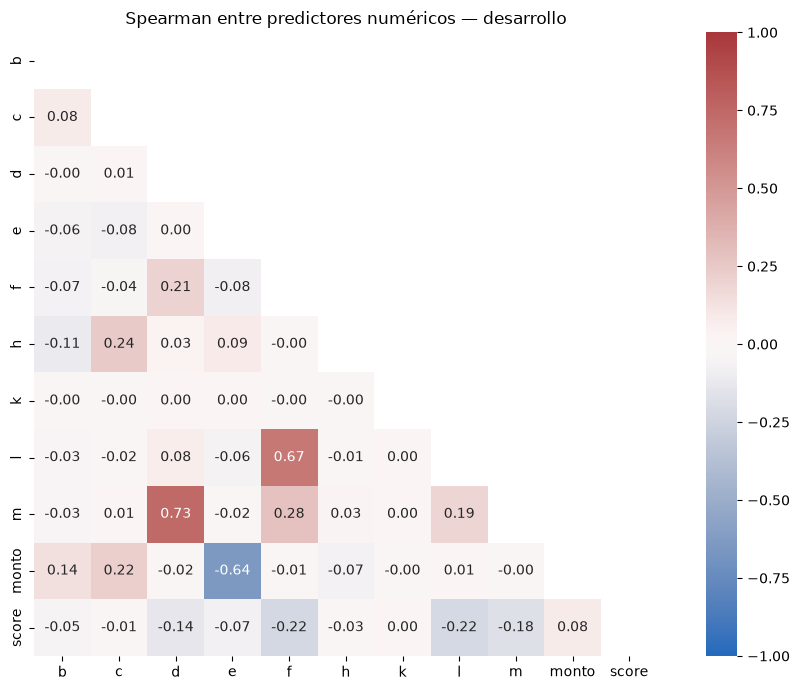

,n_observados,Spearman,Pearson
par,,,
d / m,114174,0.735,0.592
f / l,114495,0.667,0.076
e / monto,114506,-0.644,-0.059


In [13]:
spearman = development[numeric_columns].corr(method="spearman")
pearson = development[numeric_columns].corr(method="pearson")

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones(spearman.shape, dtype=bool))
sns.heatmap(
    spearman,
    mask=mask,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="vlag",
    annot=True,
    fmt=".2f",
    square=True,
    ax=ax,
)
ax.set_title("Spearman entre predictores numéricos — desarrollo")
fig.tight_layout()
plt.show()

comparison = pd.DataFrame(
    [
        {
            "par": f"{first} / {second}",
            "n_observados": len(development[[first, second]].dropna()),
            "Spearman": spearman.loc[first, second],
            "Pearson": pearson.loc[first, second],
        }
        for first, second in [("d", "m"), ("f", "l"), ("e", "monto")]
    ]
).set_index("par")
display(comparison.round(3))

**Conclusión.** `d / m` se asocian con los dos métodos (**0,735** y **0,592**). Los otros dos pares
muestran por qué elegir la medida importa: en `f / l`, Spearman da **0,667** y Pearson **0,076**; en
`e / monto`, **−0,644** contra **−0,059**. Hay una relación monótona fuerte que la escala original no
refleja como recta. La discrepancia sugiere revisar forma y extremos, pero no prueba por sí sola que los
outliers sean la causa.

**No eliminamos ninguna variable por correlación.** Los modelos de árbol toleran predictores
correlacionados, y con 11 numéricas el costo de conservarlas es bajo frente al riesgo de descartar señal.

## 8. País y tiempo

Dos preguntas de estabilidad: ¿el fenómeno se comporta igual entre segmentos?, y ¿es estable en el
tiempo, o el corte del 13 de abril cae en un régimen atípico?

Sobre países, mantenemos **una sola notebook segmentada** en lugar de un EDA por país: así las mismas
reglas y gráficos se aplican a todos sin duplicar código. Separarlos tendría sentido si un país exigiera
fuentes o definiciones distintas. Mostramos los cuatro con más transacciones y agrupamos el resto solo
para esta tabla; **Otros** es heterogéneo y no se lee como un país.

In [14]:
country_counts = development.g.value_counts()
main_countries = country_counts.head(4).index
country_labels = development.g.where(development.g.isin(main_countries), "Otros")
country_labels = country_labels.mask(development.g.isna(), "Ausente")
country_data = development.assign(pais=country_labels)

country_summary = summarize_segments(country_data, ["pais"])
country_summary["volumen_pct"] = 100 * country_summary.transacciones / len(development)
country_summary["o_ausente_pct"] = country_data.groupby("pais").o.apply(
    lambda values: values.isna().mean() * 100
)
display(
    country_summary[
        ["transacciones", "volumen_pct", "fraudes", "fraude_pct", "monto_mediano", "o_ausente_pct"]
    ]
    .sort_values("transacciones", ascending=False)
    .round(2)
)

,transacciones,volumen_pct,fraudes,fraude_pct,monto_mediano,o_ausente_pct
pais,,,,,,
BR,86441,75.49,4880,5.65,19.00,72.29
AR,23377,20.42,934,4.00,29.22,72.93
UY,2244,1.96,27,1.20,23.53,75.31
US,1608,1.40,46,2.86,23.74,73.57
Otros,719,0.63,34,4.73,17.76,71.63
Ausente,117,0.10,8,6.84,16.89,74.36


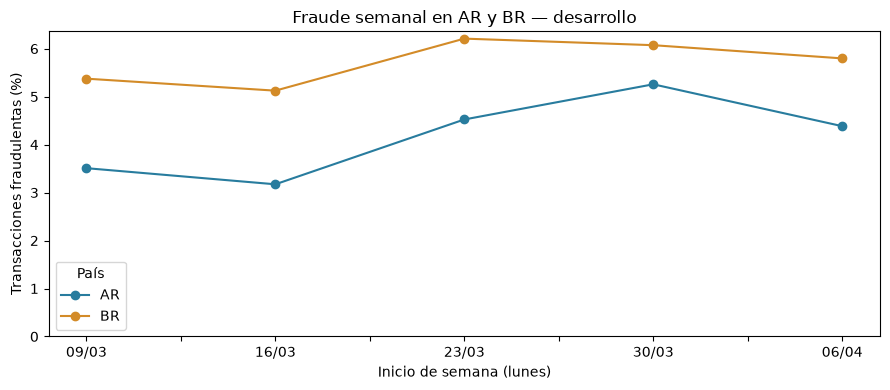

transacciones  fraudes  fraude_pct
semana     g                                     
2020-03-09 AR           5757      202        3.51
           BR          17843      959        5.37
2020-03-16 AR           5768      183        3.17
           BR          18460      946        5.12
2020-03-23 AR           4023      182        4.52
           BR          15251      947        6.21
2020-03-30 AR           2644      139        5.26
           BR          14014      851        6.07
2020-04-06 AR           4630      203        4.38
           BR          18681     1083        5.80

In [15]:
# Semanas lunes a domingo. Las semanas incompletas se excluyen solo de este gráfico.
weekly_data = development.loc[development.g.isin(["AR", "BR"])].copy()
weekly_data["semana"] = weekly_data.fecha.dt.to_period("W-SUN").dt.start_time
weekly_summary = summarize_segments(weekly_data, ["semana", "g"])
first_day = development.fecha.min().normalize()
last_day = development.fecha.max().normalize()
week_start = weekly_summary.index.get_level_values("semana")
weekly_summary = weekly_summary.loc[
    (week_start >= first_day) & (week_start + pd.Timedelta(days=6) <= last_day)
]
weekly_rates = weekly_summary.fraude_pct.unstack("g")
weekly_rates.index = weekly_rates.index.strftime("%d/%m")

fig, ax = plt.subplots(figsize=(9, 4))
weekly_rates.plot(ax=ax, marker="o", color=["#287C9E", "#D38B28"])
ax.set(
    title="Fraude semanal en AR y BR — desarrollo",
    xlabel="Inicio de semana (lunes)",
    ylabel="Transacciones fraudulentas (%)",
    ylim=(0, None),
)
ax.legend(title="País")
fig.tight_layout()
plt.show()
display(weekly_summary[["transacciones", "fraudes", "fraude_pct"]].round(2))

**Conclusión.** BR concentra el **75,5%** del volumen con **5,65%** de fraude y AR el 20,4% con
**4,00%**. UY y US tienen tasas más bajas (1,20% y 2,86%) pero solo **27 y 46 fraudes** observados: con
ese soporte, la diferencia no es interpretable. El resultado global está dominado por BR, así que
conviene reportar desempeño global **y** por país, aunque eso todavía no justifica modelos separados.
La comparación de montos entre países depende del supuesto de moneda común, que sigue sin confirmar.

En el tiempo, las tasas semanales de AR y BR se mueven en una banda estrecha —AR entre 3,17% y 5,26%,
BR entre 5,12% y 6,21%— sin saltos ni tendencia marcada, y BR está por encima de AR en todas las
semanas. Eso respalda la decisión de la sección 1: **el corte del 13 de abril no separa dos regímenes
distintos**, sino un período razonablemente homogéneo. Cada punto es una tasa semanal, no un número de
fraudes, y los volúmenes distintos implican distinta precisión: leer siempre la tabla junto al gráfico.

## 9. Conclusiones para la siguiente etapa

**La vara, medida fuera de muestra.** Aprobar todo rinde **721.774** sobre desarrollo y una predicción
perfecta daría **1.150.919**: hay **429.145** en disputa. La mejor regla de un corte sobre `score` mejora
**+23.999** medido fuera de muestra, no los +35.444 que sugiere el ajuste in-sample. Ese es el número a
superar, y el modelo se juzga por cuánto de la brecha cierra, no por su AUC.

**El umbral es 0,2, no 0,5, y no depende del monto.** Como la decisión usa el valor de la probabilidad y
no el orden, el modelo necesita estar **calibrado**: un AUC alto con probabilidades mal calibradas decide
mal con este umbral. El mismo 0,2 gobierna los segmentos, sobre la participación del fraude en el monto.

**Dónde está la señal, y cuánto vale.** `o` es lo más fuerte del dataset y su ausencia es informativa
(2,11% cuando falta contra 22,74% en `o = N`): el indicador de nulo debe ser una feature explícita.
Rechazar `o = N` valdría +109.637 y su cruce con `n = 0` concentra 36,95% de fraude. `n`, `score` y la
madrugada aportan; `p`, `h` y `a` tienen lift mayor a 1 pero rechazarlos destruye valor. Ninguna de estas
reglas es una política: son el mapa de dónde el modelo tiene que encontrar valor.

**Sin perfil por usuario.** No hay identificador de usuario utilizable; `j` se comporta como categoría de
segmento y `h` parece traer el historial agregado. `j` y `g` necesitan encoding con disciplina temporal,
calculado solo con el pasado de cada fold.

**`k` como vara de ruido.** AUC 0,5061. Al leer importancias, lo que puntúe por debajo merece revisión.

**Modelo.** Un modelo global que incluya país, evaluado también por país. El predominio de BR podría
favorecer sus patrones, pero eso es una hipótesis a validar, no un resultado del EDA. No se escala
todavía: los árboles parten de las escalas originales. Las features se construyen en
`02_feature_engineering.ipynb` y las decisiones de modelo quedan en `03_modeling.ipynb`.

### Los supuestos, al cierre

| Supuesto | Resultado |
|---|---|
| `monto` en unidad monetaria común | **Abierto.** Requiere diccionario de datos. Si mezcla monedas, todas las sumas en pesos de esta notebook deben recalcularse sobre una unidad común |
| `g` es el país | **Abierto.** Los códigos lo sugieren; las conclusiones por país son hipótesis |
| `score` disponible al decidir | **Evaluado: compatible con un puntaje previo a la decisión**, no con una fuga. Igual se medirá el modelo con y sin `score` para no depender de la respuesta |
| Etiquetas sin demora relevante | **Evaluado: sin patrón de truncamiento** en la ventana observable. `gap = 0` se mantiene como provisional; si el dueño del dato informa una demora, basta volver a correr con ese `gap_days` |

**Observación abierta.** El tramo 0-20 de `score` tiene 3,86% de fraude sobre 25.184 transacciones,
muy por encima del piso de 0,36% del tramo 30-40. No es ruido y no le inventamos explicación.

In [16]:
assert len(clean) == len(df)
pd.testing.assert_series_equal(clean.monto, df.monto)
print("Verificado: filas y montos originales conservados.")

Verificado: filas y montos originales conservados.
